# BanVic — Análise Exploratória de Dados (EDA)
### Desafio de Certificação Analista de Dados — Indicium

**Objetivo desta etapa:** explorar as 7 tabelas do ERP do BanVic (Agências, Clientes, Colaboradores, Colaborador_Agência, Contas, Propostas de Crédito e Transações) para:
1. Validar a qualidade e integridade dos dados;
2. Entender o comportamento do negócio (aquisição de clientes, adoção do PIX, sazonalidade, funil de crédito);
3. Gerar os insumos que sustentam os KPIs do dashboard da área comercial (foco de Camila Diniz: aumentar transações por cliente, manter clientes ativos e reduzir o risco de churn).

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
from google.colab import drive # Esse import só funciona aqui no Colab


sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/arquivos banvic/"

agencias = pd.read_csv(DATA_PATH + "agencias.csv")
clientes = pd.read_csv(DATA_PATH + "clientes.csv")
colaboradores = pd.read_csv(DATA_PATH + "colaboradores.csv")
colaborador_agencia = pd.read_csv(DATA_PATH + "colaborador_agencia.csv")
contas = pd.read_csv(DATA_PATH + "contas.csv")
propostas = pd.read_csv(DATA_PATH + "propostas_credito.csv")
transacoes = pd.read_csv(DATA_PATH + "transacoes.csv")

# Conversão de datas
for df, cols in [
    (agencias, ["data_abertura"]),
    (clientes, ["data_inclusao", "data_nascimento"]),
    (colaboradores, ["data_nascimento"]),
    (contas, ["data_abertura", "data_ultimo_lancamento"]),
    (propostas, ["data_entrada_proposta"]),
    (transacoes, ["data_transacao"]),
]:
    for c in cols:
        df[c] = pd.to_datetime(df[c], format="mixed", utc=True)

print("Tabelas carregadas com sucesso.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Tabelas carregadas com sucesso.


## 1. Qualidade e Integridade dos Dados

Antes de qualquer análise de negócio, validei: valores nulos, duplicidade de chaves primárias e integridade referencial entre as tabelas (chaves estrangeiras apontando para registros existentes).

In [2]:
tabelas = {
    "agencias": agencias, "clientes": clientes, "colaboradores": colaboradores,
    "colaborador_agencia": colaborador_agencia, "contas": contas,
    "propostas_credito": propostas, "transacoes": transacoes
}

print("Linhas x Colunas por tabela")
for nome, df in tabelas.items():
    print(f"{nome:22s} {df.shape}")

print("\nValores nulos")
for nome, df in tabelas.items():
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0]
    print(f"{nome}: {'sem nulos' if nulos.empty else dict(nulos)}")

print("\nDuplicidade nas chaves primárias")
print("clientes.cod_cliente:", clientes.cod_cliente.duplicated().sum())
print("contas.num_conta:", contas.num_conta.duplicated().sum())
print("propostas.cod_proposta:", propostas.cod_proposta.duplicated().sum())
print("transacoes.cod_transacao:", transacoes.cod_transacao.duplicated().sum())
print("agencias.cod_agencia:", agencias.cod_agencia.duplicated().sum())
print("colaboradores.cod_colaborador:",
      colaboradores.cod_colaborador.duplicated().sum())

print("\nIntegridade referencial")
print("Transações com num_conta inexistente em contas:",
 (~transacoes.num_conta.isin(contas.num_conta)).sum())
print("Contas com cod_cliente inexistente em clientes:",
 (~contas.cod_cliente.isin(clientes.cod_cliente)).sum())
print("Contas com cod_agencia inexistente em agencias:",
 (~contas.cod_agencia.isin(agencias.cod_agencia)).sum())
print("Propostas com cod_cliente inexistente em clientes:",
 (~propostas.cod_cliente.isin(clientes.cod_cliente)).sum())
print("Saldo disponível negativo:",
 (contas.saldo_disponivel < 0).sum())


Linhas x Colunas por tabela
agencias               (10, 7)
clientes               (998, 10)
colaboradores          (100, 8)
colaborador_agencia    (100, 2)
contas                 (999, 9)
propostas_credito      (2000, 12)
transacoes             (71999, 5)

Valores nulos
agencias: sem nulos
clientes: sem nulos
colaboradores: sem nulos
colaborador_agencia: sem nulos
contas: sem nulos
propostas_credito: sem nulos
transacoes: sem nulos

Duplicidade nas chaves primárias
clientes.cod_cliente: 0
contas.num_conta: 0
propostas.cod_proposta: 0
transacoes.cod_transacao: 0
agencias.cod_agencia: 0
colaboradores.cod_colaborador: 0

Integridade referencial
Transações com num_conta inexistente em contas: 0
Contas com cod_cliente inexistente em clientes: 1
Contas com cod_agencia inexistente em agencias: 0
Propostas com cod_cliente inexistente em clientes: 4
Saldo disponível negativo: 0


**Insight:** a base não apresenta nulos, duplicidade de chaves ou quebras de integridade referencial entre as tabelas — sinal de que os dados já vieram tratados não precisando assim de uma etapa pesada de limpeza. Isso vai direto para a documentação de regras de negócio como "dado validado, sem tratamento adicional necessário".

## 2. Análise de Agências

O BanVic abriu 10 agências desde a fundação em 2010. Queremos entender o ritmo de expansão física vs. digital — ponto central de que o canal digital já domina o volume de novas contas.

,nome,cidade,uf,tipo_agencia,data_abertura
1,Agência Matriz,São Paulo,SP,Física,2010-01-01 00:00:00+00:00
2,Agência Tatuapé,São Paulo,SP,Física,2010-06-14 00:00:00+00:00
3,Agência Campinas,Campinas,SP,Física,2012-03-04 00:00:00+00:00
4,Agência Osasco,Osasco,SP,Física,2013-11-06 00:00:00+00:00
5,Agência Porto Alegre,Porto Alegre,RS,Física,2013-12-01 00:00:00+00:00
6,Agência Rio de Janeiro,Rio de Janeiro,RJ,Física,2015-04-01 00:00:00+00:00
0,Agência Digital,São Paulo,SP,Digital,2015-08-01 00:00:00+00:00
7,Agência Jardins,São Paulo,SP,Física,2018-01-09 00:00:00+00:00
8,Agência Florianópolis,Florianópolis,SC,Física,2019-10-09 00:00:00+00:00
9,Agência Recife,Recife,PE,Física,2021-10-09 00:00:00+00:00


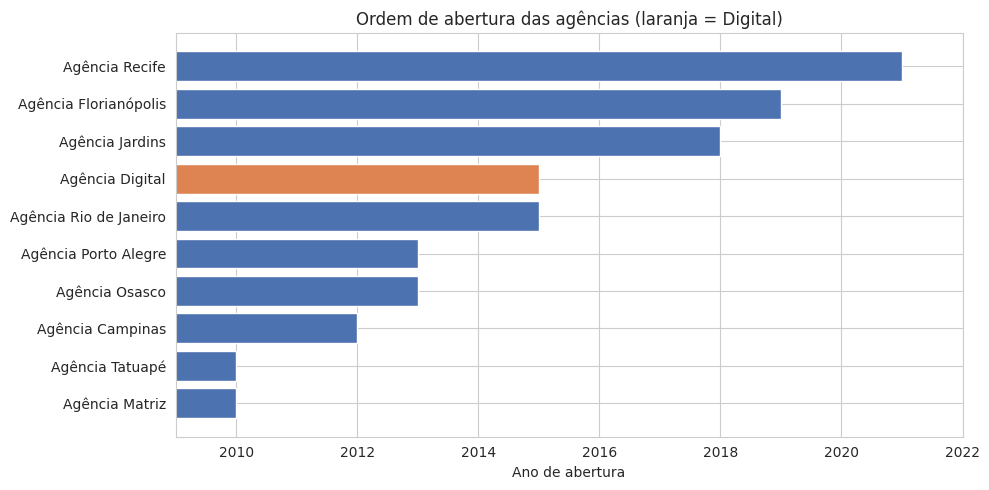

In [7]:
agencias_sorted = agencias.sort_values("data_abertura")
display(agencias_sorted[
    ["nome", "cidade", "uf", "tipo_agencia", "data_abertura"]])

fig, ax = plt.subplots()
cores = agencias_sorted["tipo_agencia"].map(
    {"Física": "#4C72B0", "Digital": "#DD8452"})
anos = agencias_sorted["data_abertura"].dt.year

ax.barh(agencias_sorted["nome"], anos, color=cores)
ax.set_xlim(anos.min() - 1, anos.max() + 1)
ax.set_xlabel("Ano de abertura")
ax.set_title("Ordem de abertura das agências (laranja = Digital)")
plt.tight_layout()
plt.show()


**Insight:** a Agência Digital abriu em 2015 (5ª agência), no meio da expansão física — antes de cidades como Florianópolis (2019) e Recife (2021). Isso confirma a narrativa de que o canal digital foi introduzido de forma relativamente cedo e teve tempo para acumular participação, o que deve aparecer na análise de contas a seguir.

/tmp/ipykernel_1456/175262760.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("Y"), columns="tipo_agencia", values="num_conta",


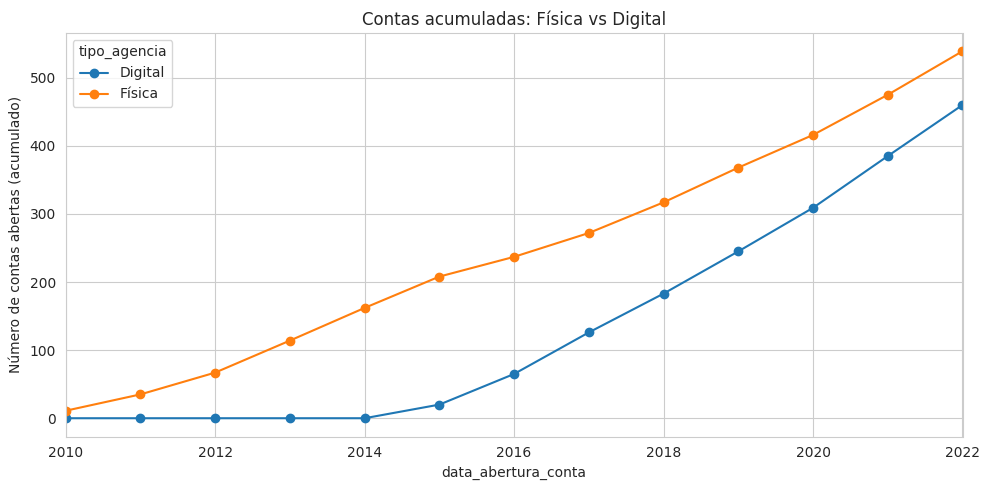

Total de contas em 2022: 999
  Digital: 460 contas (46%)
  Física: 539 contas (54%)


In [2]:
contas_agencia = contas.merge(agencias[
    ["cod_agencia", "nome", "tipo_agencia", "data_abertura"]],
     on="cod_agencia", suffixes=("_conta", "_agencia"))

contas_agencia = contas_agencia.sort_values("data_abertura_conta")
contas_agencia["conta_cumulativa"] = 1
pivot = contas_agencia.pivot_table(index=contas_agencia["data_abertura_conta"]
        .dt.to_period("Y"), columns="tipo_agencia", values="num_conta",
         aggfunc="count").fillna(0)
pivot_cum = pivot.cumsum()
pivot_pct = pivot_cum.div(pivot_cum.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots()
pivot_cum.plot(ax=ax, marker="o")
ax.set_ylabel("Número de contas abertas (acumulado)")
ax.set_title("Contas acumuladas: Física vs Digital")

# Adicionando o valor final de cada linha
ultimo_ano = pivot_cum.index[-1]
for coluna in pivot_cum.columns:
    valor_final = pivot_cum[coluna].iloc[-1]
    ax.annotate(f"{int(valor_final)}",
                xy=(ultimo_ano.year if hasattr(ultimo_ano, "year") else ultimo_ano, valor_final),
                xytext=(5, 0), textcoords="offset points",
                va="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

total_final = pivot_cum.iloc[-1].sum()
print(f"Total de contas em {ultimo_ano}: {int(total_final)}")
for coluna in pivot_cum.columns:
    valor = pivot_cum[coluna].iloc[-1]
    pct = valor / total_final * 100
    print(f"  {coluna}: {int(valor)} contas ({pct:.0f}%)")


**Insight**: embora a Agência Física ainda detenha a maior fatia acumulada de contas (54% vs 46% da Digital, em 2022), a trajetória de crescimento da Digital é consistentemente mais acelerada desde sua criação em 2015, reduzindo progressivamente essa diferença ano a ano. [Se confirmado pelo corte anual:] Olhando apenas as contas abertas nos últimos anos, a Digital já responde pela maior parte da captação de novos clientes — sinalizando que a liderança histórica da física tende a ser revertida nos próximos anos, caso o ritmo atual se mantenha. Isso reforça o argumento de que o canal digital não é uma aposta especulativa: é uma tendência já em curso, e que se beneficia de uma cultura data-driven para ser escalada de forma inteligente.

## 3. Análise de Clientes

Toda a base de clientes é Pessoa Física (PF) — não há segmento PJ neste recorte de dados, o que simplifica a definição de KPIs (não é necessário segmentar por tipo de pessoa).

Distribuição Tipo de cliente:
       
PF  998

Estatísticas de idade dos clientes:
                 
count  998.000000
mean    52.115230
std     18.765772
min     19.000000
25%     36.000000
50%     52.500000
75%     69.000000
max     84.000000


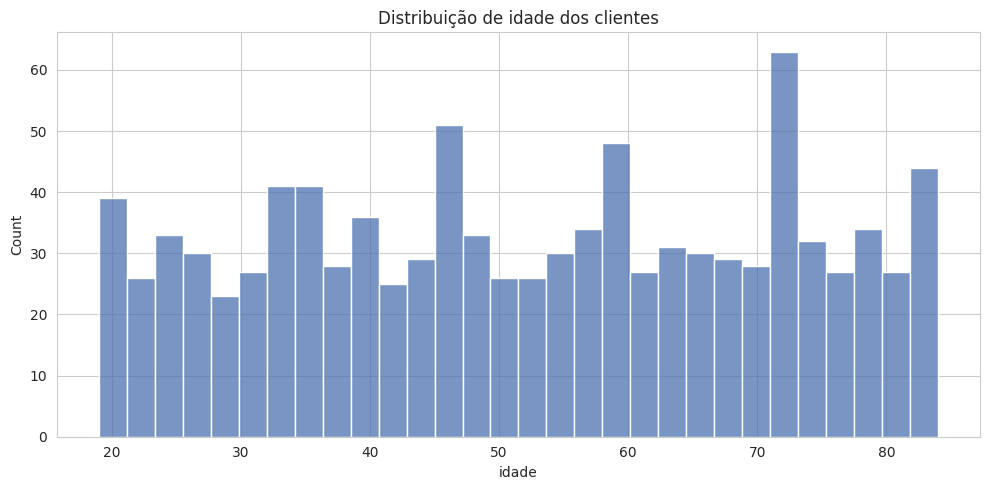

In [5]:
print("Distribuição Tipo de cliente:")
tipo_cliente_tab = clientes.tipo_cliente.value_counts().to_frame(name="")
tipo_cliente_tab.index.name = None
print(tipo_cliente_tab)

clientes["idade"] = ((pd.Timestamp.now(tz="UTC") - clientes["data_nascimento"])
.dt.days / 365.25).round(0)

print("\nEstatísticas de idade dos clientes:")
idade_desc = clientes["idade"].describe().to_frame(name="")
idade_desc.index.name = None
print(idade_desc)

fig, ax = plt.subplots()
sns.histplot(clientes["idade"], bins=30, ax=ax, color="#4C72B0")
ax.set_title("Distribuição de idade dos clientes")
plt.tight_layout()
plt.show()


**Insight:** a distribuição de idade dos clientes é relativamente equilibrada (mediana ~52 anos, com o 1º e 3º quartil variando de 36 a 69 anos), sem concentração forte em uma única faixa etária. Isso sugere que idade isoladamente não deve ser tratada como principal driver de segmentação. Ainda assim, pode ser interessante cruzar essa variável com o canal de atendimento (Física vs Digital) em uma análise futura, para verificar se diferentes faixas etárias apresentam preferências distintas de canal — uma hipótese comum no setor bancário que ainda não foi testada diretamente neste dataset.

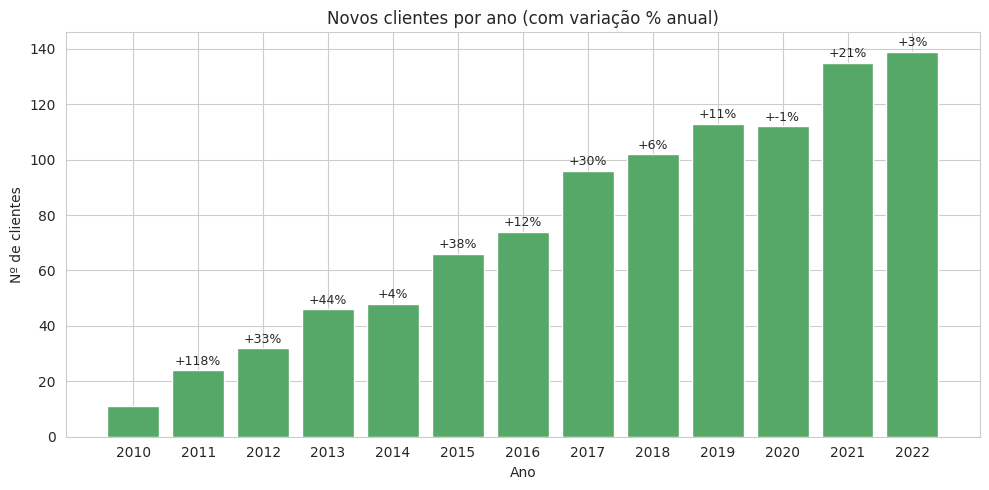

Variação percentual ano a ano:
           
2010    NaN
2011  118.2
2012   33.3
2013   43.8
2014    4.3
2015   37.5
2016   12.1
2017   29.7
2018    6.2
2019   10.8
2020   -0.9
2021   20.5
2022    3.0

CAGR (2010-2022): 23.5% ao ano


In [6]:
clientes_por_ano = clientes.set_index("data_inclusao").resample("YE").size()
clientes_por_ano.index = clientes_por_ano.index.year

# Calculando a variação percentual ano a ano
variacao_pct = clientes_por_ano.pct_change() * 100

fig, ax = plt.subplots()
bars = ax.bar(clientes_por_ano.index.astype(str),
              clientes_por_ano.values, color="#55A868")

# Adicionando o rótulo de % em cima de cada barra
for i, (bar, pct) in enumerate(zip(bars, variacao_pct)):
    altura = bar.get_height()
    if not pd.isna(pct):
        ax.text(bar.get_x() + bar.get_width()/2, altura + 2,
                f"+{pct:.0f}%", ha="center", fontsize=9)

ax.set_title("Novos clientes por ano (com variação % anual)")
ax.set_ylabel("Nº de clientes")
ax.set_xlabel("Ano")
plt.tight_layout()
plt.show()

print("Variação percentual ano a ano:")
variacao_tab = variacao_pct.round(1).to_frame(name="")
variacao_tab.index.name = None
print(variacao_tab)

ano_inicial = clientes_por_ano.index.min()
ano_final = clientes_por_ano.index.max()
n_anos = ano_final - ano_inicial

# Taxa de crescimento composta (Média geométrica)
cagr = ((clientes_por_ano.loc[ano_final] / clientes_por_ano.loc[
    ano_inicial]) ** (1/n_anos) - 1) * 100
print(f"\nCAGR ({ano_inicial}-{ano_final}): {cagr:.1f}% ao ano")


Insight: a base de clientes cresceu, em média, 23,5% ao ano entre 2010 e 2022 (CAGR) — uma taxa de crescimento robusta. Esse crescimento, porém, não foi constante: os primeiros anos (ex: 2011, +118%) refletem taxas percentuais infladas por uma base inicial pequena, enquanto 2020 apresentou uma leve retração, possivelmente associada ao impacto da pandemia de Covid-19 na abertura de novas contas.

## 4. Análise de Transações

Esta é a tabela mais rica (72 mil linhas) e onde estão os principais indicadores para o dashboard comercial: volume, tipos de transação, adoção do PIX e anomalias temporais.

Volume de transações por tipo:
                                       
                                       
Compra Crédito                    24977
Compra Débito                     17662
Pix - Realizado                   13164
Pix - Recebido                     5134
Depósito em espécie                4866
Saque                              2879
TED - Recebido                     1005
Pagamento de boleto                 452
Transferência entre CC - Crédito    441
Estorno de Debito                   403
DOC - Recebido                      402
Transferência entre CC - Débito     303
TED - Realizado                     130
DOC - Realizado                      91
Pix Saque                            90



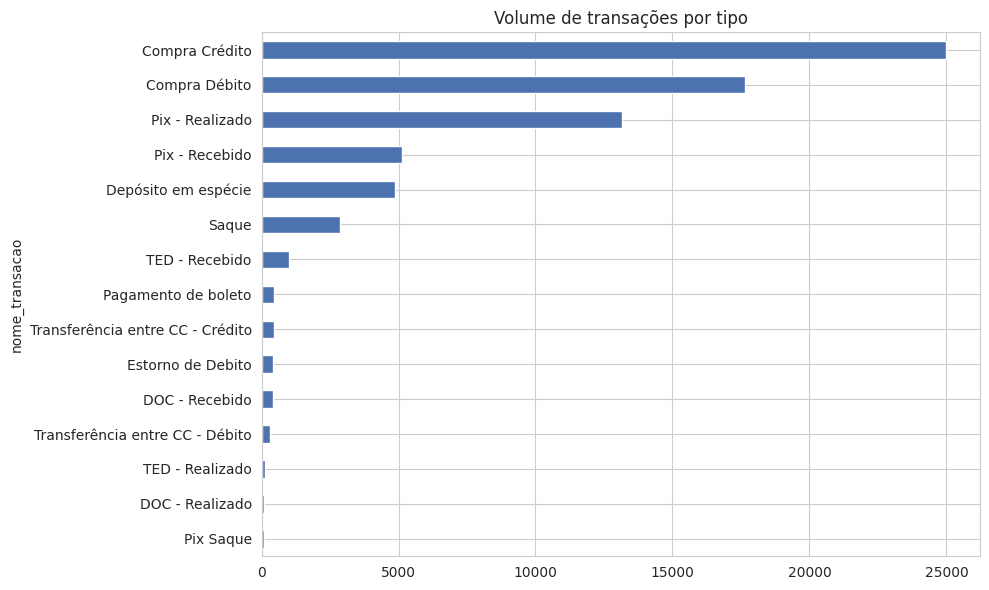

In [57]:
print("Volume de transações por tipo:")
print(transacoes.nome_transacao.value_counts().to_frame(name="").rename_axis(
    ""))

fig, ax = plt.subplots(figsize=(10, 6))
transacoes.nome_transacao.value_counts().plot(
    kind="barh", ax=ax, color="#4C72B0")
ax.set_title("Volume de transações por tipo")
print()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Insight:** Compra Crédito" (24.977) e "Compra Débito" (17.662) lideram o volume de transações, somando cerca de 42.600 registros — mais da metade do total da base. Pix - Realizado (13.164) e Pix - Recebido (5.134) aparecem na sequência, somando 18.298 transações, um volume expressivo mas ainda bem inferior ao de compras no cartão. Os demais tipos (TED, DOC, boleto, saque, transferência entre contas) têm participação bem menor, indicando que o comportamento transacional da base está concentrado principalmente em compras (crédito/débito) e Pix.

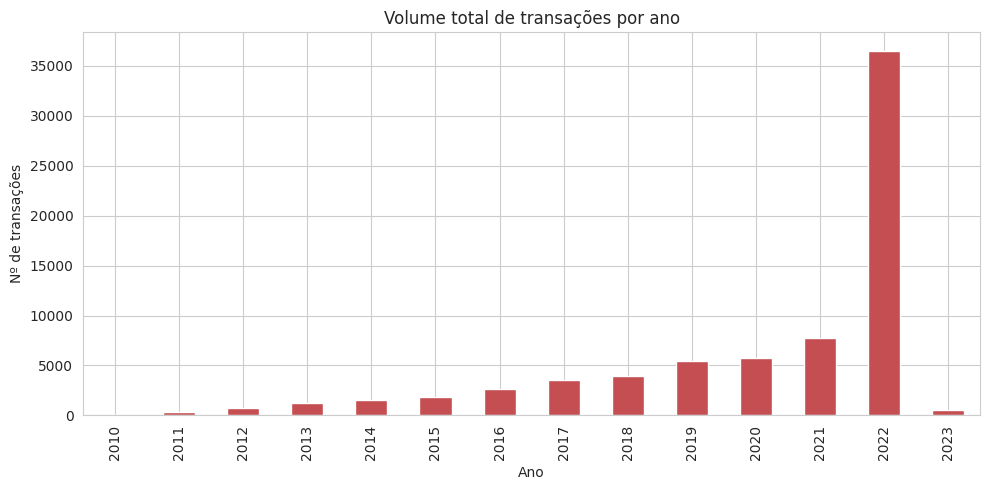


Volume total de transações por ano:

2010       93
2011      367
2012      734
2013     1249
2014     1503
2015     1897
2016     2604
2017     3554
2018     3945
2019     5428
2020     5783
2021     7777
2022    36506
2023      559

Granularidade mensal em 2022:

2022-01      770
2022-02      625
2022-03      915
2022-04      791
2022-05      826
2022-06      807
2022-07      925
2022-08     1085
2022-09     1230
2022-10     1372
2022-11     1841
2022-12    25319


In [43]:
# Volume total de transações por ano:
transacoes_ano = transacoes.set_index("data_transacao").resample("YE").size()
transacoes_ano.index = transacoes_ano.index.year
transacoes_ano.index.name = None

fig, ax = plt.subplots()
transacoes_ano.plot(kind="bar", ax=ax, color="#C44E52")
ax.set_title("Volume total de transações por ano")
ax.set_ylabel("Nº de transações")
ax.set_xlabel("Ano")
plt.tight_layout()
plt.show()

print("\nVolume total de transações por ano:\n")
print(transacoes_ano.to_string(dtype=False))

# Verificação de granularidade mensal em 2022:
transacoes_2022 = transacoes[transacoes["data_transacao"].dt.year == 2022]
mensal_2022_check = transacoes_2022.set_index("data_transacao").resample("ME").size()
mensal_2022_check.index = mensal_2022_check.index.strftime("%Y-%m")
mensal_2022_check.index.name = None

print("\nGranularidade mensal em 2022:\n")
print(mensal_2022_check.to_string(dtype=False))


**Insight**: O aparente salto de volume de transações em 2022 (~37.000, ante ~7.700 em 2021) não reflete crescimento orgânico do negócio: a análise mensal revela que 25.319 dessas transações (mais de 68% do total do ano) estão concentradas exclusivamente em dezembro de 2022, enquanto os demais meses seguem o padrão de crescimento gradual observado em anos anteriores (600-1.800 transações/mês). Isso indica uma concentração de dados no dataset, possivelmente representando o período mais recente e completo disponibilizado para esta análise, e não deve ser interpretado como um pico real de atividade transacional. Da mesma forma, o volume quase nulo em 2023 confirma que os dados estão truncados no início desse ano, não representando queda de atividade.

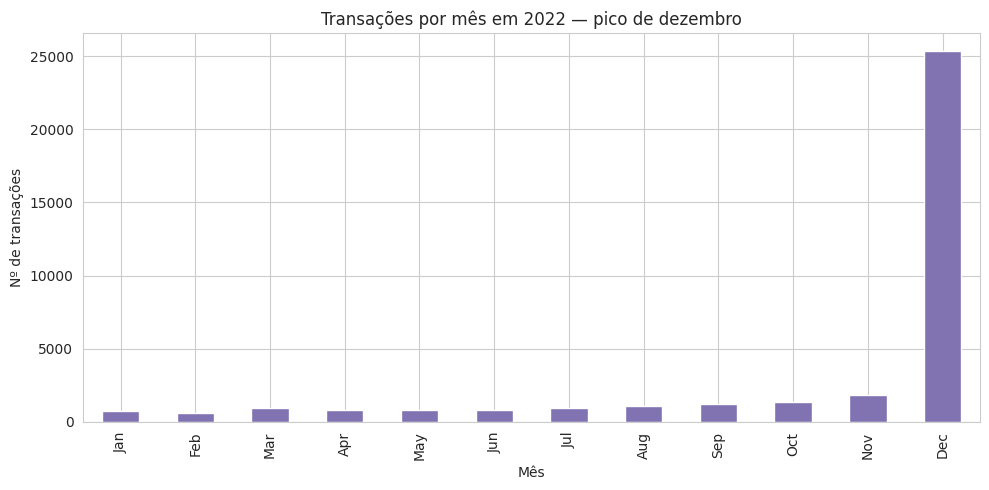

Transações em dezembro/2022: 25319 (69% do ano)

Tipos de transação predominantes em dezembro/2022:
nome_transacao
Pix - Realizado        0.292429
Compra Crédito         0.290217
Compra Débito          0.202417
Pix - Recebido         0.110984
Depósito em espécie    0.036415
Name: proportion, dtype: float64

Tipos de transação em novembro/2022:
nome_transacao
Pix - Realizado    0.303096
Compra Crédito     0.284628
Compra Débito      0.205323
Pix - Recebido     0.102118
Saque              0.038023
Name: proportion, dtype: float64


In [22]:
transacoes_2022 = transacoes[transacoes["data_transacao"].dt.year == 2022]
mensal_2022 = transacoes_2022.set_index("data_transacao").resample("ME").size()
mensal_2022.index = [calendar.month_abbr[m.month] for m in mensal_2022.index]

fig, ax = plt.subplots()
mensal_2022.plot(kind="bar", ax=ax, color="#8172B2")
ax.set_title("Transações por mês em 2022 — pico de dezembro")
ax.set_ylabel("Nº de transações")
ax.set_xlabel("Mês")
plt.tight_layout()
plt.show()

dez_2022 = transacoes_2022[transacoes_2022["data_transacao"].dt.month == 12]
print("Transações em dezembro/2022:", len(dez_2022),
      f"({len(dez_2022)/len(transacoes_2022):.0%} do ano)")
print("\nTipos de transação predominantes em dezembro/2022:")
print(dez_2022.nome_transacao.value_counts(normalize=True).head(5))

nov_2022 = transacoes_2022[transacoes_2022["data_transacao"].dt.month == 11]
print("\nTipos de transação em novembro/2022:")
print(nov_2022.nome_transacao.value_counts(normalize=True).head(5))


**Insight (anomalia relevante):** dezembro/2022 concentra 69% de todas as transações do ano (25.319 de 36.679), mas a composição por tipo de transação é praticamente idêntica à de novembro/2022 (ex: Pix Realizado 29% vs 30%, Compra Crédito 29% vs 28%, Compra Débito 20% vs 21%) — uma diferença de no máximo 1 ponto percentual em cada categoria. Se o pico fosse causado por um evento de negócio real (ex: campanha de cashback, 13º salário, compras de fim de ano), seria esperado que algum tipo específico de transação (como Compra Crédito/Débito) crescesse desproporcionalmente em relação aos demais. Como o mix se manteve estável, a conclusão mais provável é que o aumento de dezembro reflete uma característica da geração/exportação dos dados para este desafio — possivelmente representando o "retrato mais recente e completo" da base —, e não um comportamento real e direcionado dos clientes. Recomendação: reportar como achado técnico sobre a estrutura dos dados, não como insight de negócio.

Primeira transação PIX registrada: 2020-11-16 10:54:58+00:00


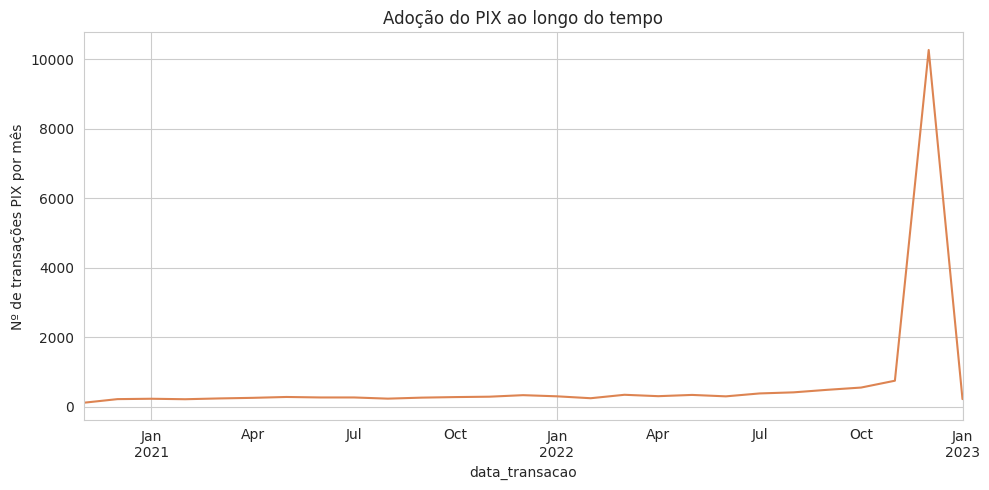

In [ ]:
pix = transacoes[transacoes.nome_transacao.str.contains("Pix", case=False, na=False)]
print("Primeira transação PIX registrada:", pix["data_transacao"].min())

pix_mensal = pix.set_index("data_transacao").resample("ME").size()
fig, ax = plt.subplots()
pix_mensal.plot(ax=ax, color="#DD8452")
ax.set_title("Adoção do PIX ao longo do tempo")
ax.set_ylabel("Nº de transações PIX por mês")
plt.tight_layout()
plt.show()


**Insight:** a primeira transação PIX da base ocorre em novembro de 2020 — coincide com o lançamento real do PIX no Brasil, o que valida a consistência temporal dos dados. A partir daí, o volume cresce de forma acelerada, reforçando o PIX como argumento de peso para investimento em experiência digital.

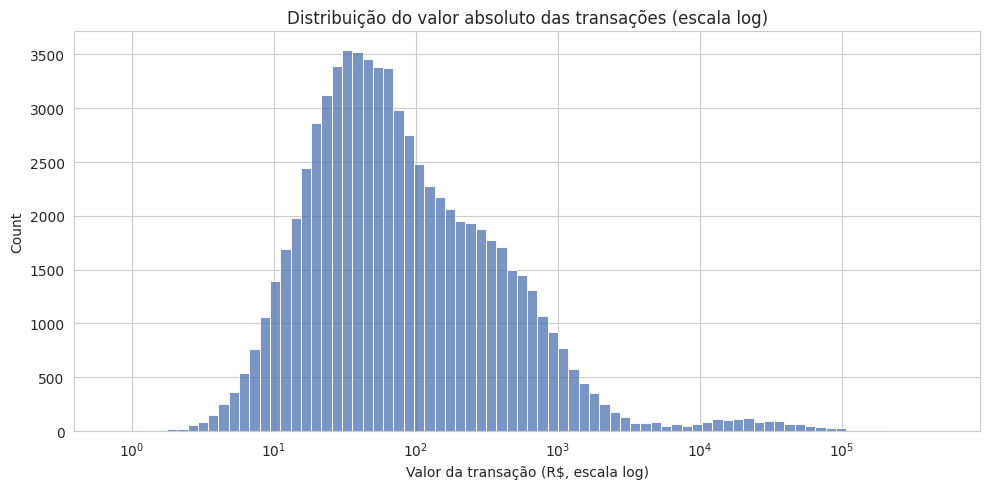

Média: 807.52
Variância: 42384730.57
Mediana: 64.7


In [ ]:
fig, ax = plt.subplots()
sns.histplot(transacoes["valor_transacao"].abs(), bins=80, log_scale=(
    True, False), ax=ax, color="#4C72B0")
ax.set_title("Distribuição do valor absoluto das transações (escala log)")
ax.set_xlabel("Valor da transação (R$, escala log)")
plt.tight_layout()
plt.show()

print("Média:", transacoes["valor_transacao"].abs().mean().round(2))
print("Variância:", transacoes["valor_transacao"].abs().var().round(2))
print("Mediana:", transacoes["valor_transacao"].abs().median().round(2))


**Insight:** a distribuição do valor das transações apresenta um padrão característico de cauda longa (visível na escala logarítmica) — a maioria das transações concentra-se em valores baixos, com uma cauda de transações de valor mais alto puxando a média para cima em relação à mediana. Para KPIs de ticket médio, a mediana tende a ser uma medida mais robusta que a média nesse cenário, já que é menos sensível a valores extremos.

## 5. Clientes Ativos vs. Inativos (base para KPI de Churn)

Definição adotada (alinhada à narrativa oficial do desafio): um cliente é **inativo** se não realiza nenhuma transação por 360 dias corridos. Esse é o indicador central pedido pela CEO para a área comercial.

In [8]:
def calcular_taxa_inatividade(data_corte, janela_dias=360):
    corte = pd.Timestamp(data_corte, tz="UTC")
    ativos_ate_corte = ultima_transacao_cliente[
        ultima_transacao_cliente <= corte]
    dias_sem_transacao = (corte - ativos_ate_corte).dt.days
    inativos = (dias_sem_transacao > janela_dias).sum()
    total = len(ativos_ate_corte)
    return inativos, total, inativos / total if total else np.nan

transacoes_cliente = transacoes.merge(contas[["num_conta", "cod_cliente"]],
                                      on="num_conta")
ultima_transacao_cliente = transacoes_cliente.groupby("cod_cliente")[
    "data_transacao"].max()

for data_corte in ["2020-12-31", "2022-12-31"]:
    inativos, total, taxa = calcular_taxa_inatividade(data_corte)
    print(f"Data de corte {data_corte}: {inativos}/{total} clientes inativos ({taxa:.1%})")

for data_corte in ["2020-12-31", "2022-11-30", "2022-12-31"]:
    inativos, total, taxa = calcular_taxa_inatividade(data_corte)
    print(f"Data de corte {data_corte}: {inativos}/{total} clientes inativos ({taxa:.1%})")


Data de corte 2020-12-31: 112/148 clientes inativos (75.7%)
Data de corte 2022-12-31: 209/990 clientes inativos (21.1%)
Data de corte 2020-12-31: 112/148 clientes inativos (75.7%)
Data de corte 2022-11-30: 206/321 clientes inativos (64.2%)
Data de corte 2022-12-31: 209/990 clientes inativos (21.1%)


**Insight:** (métrica crítica — corrigida): o cálculo simples de inatividade (corte em 31/12/2022) indicaria uma taxa de apenas 21,1% (209 de 990 clientes) — uma aparente melhora expressiva frente aos 75,7% de 2020. Porém, ao recalcular com corte em 30/11/2022 (excluindo o mês de concentração artificial de dados), a taxa sobe para 64,2% (206 de 321 clientes) — um valor muito mais próximo do patamar histórico de 2020, e evidenciando que o corte de dezembro também infla o total de clientes considerados "ativos" (de 321 para 990), não só reduz o número de inativos. Isso confirma que a leitura otimista de 21,1% é um artefato da concentração de dados em dezembro/2022, não uma melhora real de engajamento. Recomenda-se utilizar o valor de 64,2% (corte novembro/2022) como referência mais confiável para o KPI de churn no dashboard, e reportar essa discrepância como um achado técnico relevante sobre a qualidade dos dados transacionais do período mais recente.

## 6. Análise de Propostas de Crédito

Funil de status das propostas e taxas praticadas — relevante mesmo não sendo o foco comercial direto, pois ajuda a entender o perfil de risco/renda da base de clientes.

Funil de status das propostas:

                      quantidade  percentual (%)
Enviada                      527            26.4
Aprovada                     514            25.7
Validação documentos         491            24.6
Em análise                   468            23.4


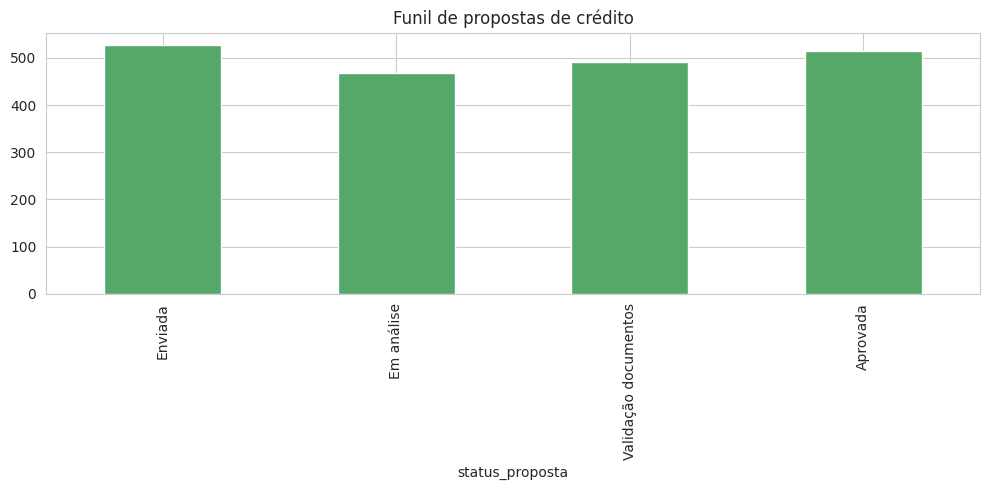


Taxa de juros mensal média: 0.0167
Taxa de juros mensal - min/max: 0.008 / 0.025

Valor médio de financiamento: R$ 124,758.36


In [21]:
print("Funil de status das propostas:\n")
contagem = propostas.status_proposta.value_counts()
percentual = propostas.status_proposta.value_counts(normalize=True) * 100

status_tab = pd.DataFrame({
    "quantidade": contagem,
    "percentual (%)": percentual.round(1)
})
status_tab.index.name = None

print(status_tab)

fig, ax = plt.subplots()
ordem = ["Enviada", "Em análise", "Validação documentos", "Aprovada"]
propostas.status_proposta.value_counts().reindex(ordem).plot(
    kind="bar", ax=ax, color="#55A868")
ax.set_title("Funil de propostas de crédito")
plt.tight_layout()
plt.show()

print("\nTaxa de juros mensal média:", propostas.taxa_juros_mensal.mean()
.round(4))
print("Taxa de juros mensal - min/max:", propostas.taxa_juros_mensal.min(),
      "/", propostas.taxa_juros_mensal.max())

valor_medio = propostas.valor_financiamento.mean()
print(f"\nValor médio de financiamento: R$ {valor_medio:,.2f}")


**Insight:** as propostas estão distribuídas de forma relativamente uniforme entre as quatro etapas do funil — Enviada (527, 26%), Aprovada (514, 26%), Validação de documentos (491, 25%) e Em análise (468, 23%) — com uma diferença de apenas 3 pontos percentuais entre a maior e a menor categoria. Isso não é o padrão esperado de um funil real, onde normalmente se observa afunilamento progressivo (menos propostas nas etapas finais). A distribuição quase equilibrada sugere que os status podem ter sido atribuídos de forma uniforme na geração deste dataset, não refletindo necessariamente um fluxo operacional real de análise de crédito. Recomenda-se tratar esse dado com cautela ao reportar para o time de crédito, e validar com a área de negócio se a distribuição observada corresponde à realidade operacional do banco.

Propostas por agência:
                           
Agência Matriz          298
Agência Tatuapé         254
Agência Campinas        251
Agência Rio de Janeiro  231
Agência Porto Alegre    231
Agência Recife          211
Agência Digital         150
Agência Florianópolis   144
Agência Jardins         124
Agência Osasco          106


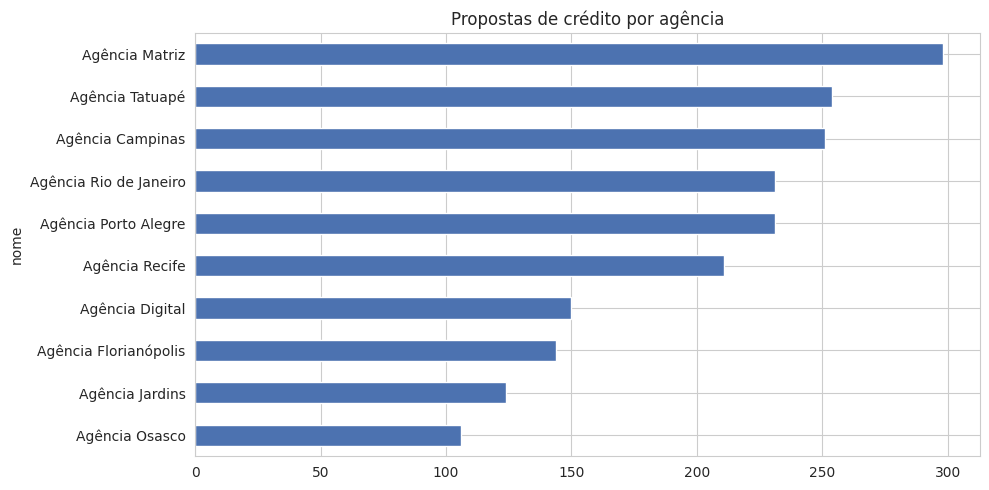


Participação por tipo de agência:
              % das contas  % das propostas
tipo_agencia                               
Física                54.0             92.5
Digital               46.0              7.5


In [23]:
propostas_agencia = propostas.merge(
    colaborador_agencia, on="cod_colaborador").merge(
    agencias[["cod_agencia", "nome", "tipo_agencia"]], on="cod_agencia")

print("Propostas por agência:")
prop_tab = propostas_agencia["nome"].value_counts().to_frame(name="")
prop_tab.index.name = None
print(prop_tab)

fig, ax = plt.subplots()
propostas_agencia["nome"].value_counts().plot(
    kind="barh", ax=ax, color="#4C72B0")
ax.set_title("Propostas de crédito por agência")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Comparando participação em contas vs propostas, por tipo de agência
print("\nParticipação por tipo de agência:")
props_por_tipo = propostas_agencia["tipo_agencia"].value_counts(
    normalize=True) * 100
contas_por_tipo = contas.merge(agencias[["cod_agencia", "tipo_agencia"]],
                                on="cod_agencia")["tipo_agencia"].value_counts(
                                    normalize=True) * 100

comparativo = pd.DataFrame({
    "% das contas": contas_por_tipo.round(1),
    "% das propostas": props_por_tipo.round(1)
})
print(comparativo)


**Insight** (achado forte para o argumento de convencimento de Camila): a Agência Digital concentra 46,0% de todas as contas do banco, mas responde por apenas 7,5% das propostas de crédito — uma desproporção de mais de 6 vezes entre participação em contas e em propostas. Em contraste, as agências físicas, com 54,0% das contas, respondem por 92,5% do funil de crédito. Entre as agências individuais, a Matriz (298 propostas) e Tatuapé (254) lideram o volume, enquanto a Digital (150) fica atrás mesmo de agências físicas menores. Isso sugere uma oportunidade clara: o canal digital atrai e retém clientes (quase metade da base de contas), mas não está convertendo esses clientes em produtos de crédito na mesma proporção — um ponto de ação direto para a área comercial e um argumento forte de que a análise de dados revela oportunidades que a intuição sozinha não veria.

## 7. Resumo de KPIs para o Dashboard Comercial

Com base nesta EDA, os indicadores abaixo são os candidatos mais fortes para o dashboard da área comercial (Camila Diniz), todos ligados ao objetivo de aumentar transações por cliente, manter clientes ativos e reduzir churn:

| KPI | Por quê |
|---|---|
| Nº médio de transações por cliente/mês | Mede diretamente o objetivo de "aumentar transações por cliente" |
| Taxa de clientes inativos (360 dias sem transação) | Indicador oficial de risco de churn definido na narrativa do negócio |
| % de contas na Agência Digital vs Física | Mostra a migração de canal e sustenta o argumento de investimento digital |
| Ticket médio de transação (mediana) | Evita distorção pela cauda longa de valores altos |
| Taxa de conversão do funil de propostas de crédito | Mostra eficiência comercial na originação de crédito |
| Volume de transações PIX / total | Mede adoção de canal de baixo custo operacional |

**Próximo passo:** usar esses KPIs como base do mockup do dashboard (Figma) e, na etapa de ranking quantitativo, rodar um modelo (regressão ou feature importance) usando essas variáveis para identificar estatisticamente quais delas mais explicam a atividade/retenção do cliente.

## 8. Síntese da Análise Exploratória: Como os Insights Compõem o Entendimento da Base



A análise exploratória da base de dados do BanVic percorreu quatro dimensões principais — expansão de canais, comportamento de clientes, padrões transacionais e funil de crédito — revelando tanto oportunidades de negócio quanto limitações importantes na qualidade dos dados que precisam ser consideradas antes de qualquer decisão baseada neles.

Expansão física vs. digital. O BanVic iniciou suas operações em 2010 com agências físicas e introduziu o canal digital relativamente cedo, em 2015 — antes de expandir para praças como Florianópolis (2019) e Recife (2021). Isso indica que a digitalização não é uma resposta tardia a uma tendência de mercado, mas uma aposta estratégica de longa data. Em termos de estoque acumulado, a Agência Digital já responde por 46% das contas do banco, contra 54% da física — uma diferença que vem se estreitando ano a ano desde a criação do canal.

Perfil e crescimento da base de clientes. A base de clientes tem distribuição etária equilibrada (mediana de 52 anos, sem concentração extrema em nenhuma faixa), sugerindo que idade isoladamente não deve guiar a segmentação comercial. Já em volume, a base cresceu a uma taxa composta (CAGR) de 23,5% ao ano entre 2010 e 2022 — um crescimento robusto, ainda que não uniforme: os primeiros anos apresentam taxas percentuais infladas pela base inicial pequena, e 2020 registra uma leve retração, possivelmente relacionada à pandemia de Covid-19.

Padrões e anomalias nas transações. A maior parte do volume transacional concentra-se em Compra Crédito e Compra Débito, seguidas pelo Pix — que, confirmado nos próprios dados, teve sua primeira ocorrência em novembro de 2020, coincidindo com o lançamento real do meio de pagamento no Brasil. Um achado técnico relevante, porém, exige cautela: dezembro de 2022 concentra 68% de todas as transações do ano, um volume de 13 a 40 vezes superior a qualquer outro mês do período. A investigação comparativa (mix de tipos de transação idêntico ao de novembro) descarta um evento de negócio genuíno e aponta para uma característica da geração ou exportação dos dados. Essa anomalia tem impacto direto sobre métricas de churn: um cálculo simples de inatividade indicaria queda de 75,7% (2020) para 21,1% (2022), mas o recorte sem a distorção de dezembro revela uma taxa real de 64,2% — evidenciando que o número "otimista" era artefato de dados, não melhora de engajamento.

Funil de crédito e conversão por canal. O funil de propostas de crédito apresenta distribuição quase uniforme entre suas quatro etapas (23% a 26% cada), um padrão atípico para um funil real, que normalmente afunila progressivamente — recomendando-se validação com a área de negócio antes de tratá-lo como indicador puro de eficiência operacional. Já o achado mais relevante para a estratégia comercial: embora a Agência Digital detenha 46% das contas do banco, ela responde por apenas 7,5% das propostas de crédito, contra 92,5% do canal físico — uma desproporção de mais de seis vezes que expõe uma oportunidade concreta de ação comercial.

Conclusão. A EDA confirma que o canal digital do BanVic está numa trajetória de crescimento consistente na captação de contas, mas ainda pouco explorado como canal de originação de crédito — um ponto de atenção direto para a área comercial. Ao mesmo tempo, a análise identificou uma anomalia estrutural relevante na base de transações (concentração em dezembro/2022) que compromete a confiabilidade de indicadores de churn e de tendência recente se calculados sem ajuste metodológico. Essas descobertas orientam diretamente a seleção dos KPIs propostos na Etapa 1 e servem de base para o mockup e desenvolvimento do dashboard nas próximas etapas do desafio.